In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics.pairwise import euclidean_distances

In [3]:
data = {
    "Hours_Studied": [2, 4, 6, 8, 10],
    "Attendance": [50, 60, 70, 80, 90],
    "Sleep_Hours": [6, 7, 5, 6, 7],
    "Shoe_Size": [6, 7, 8, 9, 10],
    "Score": [40, 50, 65, 80, 90]
}

In [4]:
df = pd.DataFrame(data)

In [5]:
X = df.drop("Score", axis=1)
y = df["Score"]

In [6]:
lasso = Lasso(alpha=0.1)

In [7]:
lasso.fit(X, y)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [8]:
for feature, coef in zip(X.columns, lasso.coef_):
    print(f'{feature}: {coef: .2f}')

Hours_Studied:  0.00
Attendance:  1.31
Sleep_Hours: -0.92
Shoe_Size:  0.00


In [9]:
student1 = X.iloc[0].values.reshape(1, -1)
student2 = X.iloc[4].values.reshape(1, -1)

In [10]:
distance = euclidean_distances(student1, student2)
print(f'Distances between the students: {distance}')

Distances between the students: [[41.]]


In [11]:
predictions = lasso.predict(X)
errors = np.abs(predictions - y)
linf_error = np.max(errors)

In [12]:
predictions

array([39.01      , 51.17333333, 66.10888889, 78.27222222, 90.43555556])

In [13]:
errors

0    0.990000
1    1.173333
2    1.108889
3    1.727778
4    0.435556
Name: Score, dtype: float64

In [14]:
linf_error

1.7277777777777459

In [16]:
A = np.array([1, 2])
B = np.array([2, -1])

dot_product = np.dot(A, B)

print(dot_product)

0


In [24]:
((np.arccos(dot_product/(distA*distB)) * 180 / np.pi))

np.float64(90.0)

In [25]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [26]:
data = {
    "income": [25000, 50000, 75000, 30000, 90000],
    "color": ['Red', 'Blue', 'Green', 'Blue', 'Red']
}
df = pd.DataFrame(data)

In [27]:
df

,income,color
0,25000,Red
1,50000,Blue
2,75000,Green
3,30000,Blue
4,90000,Red


In [38]:
encoder = OneHotEncoder(sparse_output=False)

In [39]:
color_encoded = encoder.fit_transform(df[['color']])

In [40]:
color_df = pd.DataFrame(color_encoded, columns=encoder.get_feature_names_out())

In [42]:
X = pd.concat([df['income'], color_df], axis=1)

In [43]:
X

,income,color_Blue,color_Green,color_Red
0,25000,0.0,0.0,1.0
1,50000,1.0,0.0,0.0
2,75000,0.0,1.0,0.0
3,30000,1.0,0.0,0.0
4,90000,0.0,0.0,1.0


In [44]:
income_vector = X['income'].values
red_vector = X['color_Red'].values

In [45]:
dot_product = income_vector @ red_vector

In [46]:
dot_product

np.float64(115000.0)

In [47]:
correlation = np.corrcoef(income_vector, red_vector)[0, 1]

In [48]:
correlation

np.float64(0.11349527614696626)

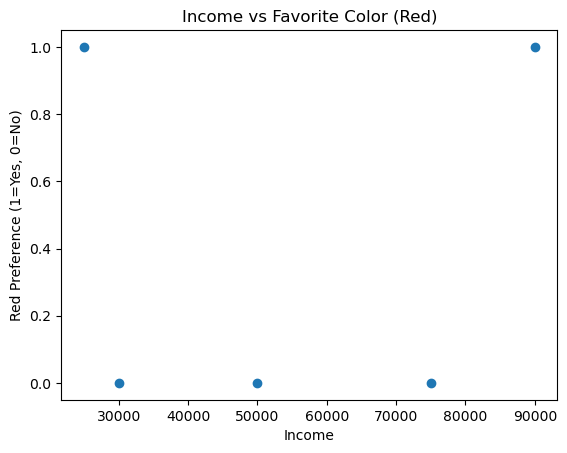

In [49]:
plt.figure()
plt.scatter(income_vector, red_vector)
plt.xlabel('Income')
plt.ylabel('Red Preference (1=Yes, 0=No)')
plt.title('Income vs Favorite Color (Red)')
plt.show()

In [50]:
from sklearn.datasets import load_digits
from sklearn.metrics.pairwise import cosine_similarity

In [51]:
digits = load_digits()
X = digits.data
y = digits.target

In [52]:
query_index = 10
query_image = X[query_index]

In [55]:
similarities = cosine_similarity([query_image], X)[0]

In [57]:
top_indices = np.argsort(similarities)[-6:][::-1]

In [58]:
top_indices

array([ 10, 334, 812, 256, 160, 848])

In [61]:
similarities[top_indices]

array([1.        , 0.96493807, 0.95939227, 0.95478125, 0.95323395,
       0.95290124])

In [71]:
cosine_similarity([query_image], X)

array([[0.91910534, 0.62022753, 0.72988784, ..., 0.78539672, 0.7999574 ,
        0.75970627]], shape=(1, 1797))

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1, 6, 1)
plt.imshow(query_image.reshape(8, 8), cmap='gray')
plt.title('Query')
plt.axis('off')

for i, idx in enumerate(top_indices[1:]):
    plt.subplot(1, 6, i+2)
    plt.imshow(X[idx].reshape(8, 8), cmap='gray')
    plt.title(f'{y[idx]}')
    plt.axis('off')

plt.suptitle('Top similar digit images (Cosine Similarity): ')
plt.show()